<a href="https://colab.research.google.com/github/sahdahx/saham-BEI/blob/main/DAC_Matfair_28_mar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis Competition (DAC) 2026**

**Data Analysis Competition (DAC) 2026** merupakan salah satu cabang lomba yang diselenggarakan dalam rangkaian kegiatan **Matematika Fair 2026** oleh Himpunan Mahasiswa Jurusan Matematika, Fakultas Matematika dan Ilmu Pengetahuan Alam, Universitas Negeri Medan. Kompetisi ini berskala nasional dan bertujuan untuk mengasah kemampuan mahasiswa dalam menganalisis data, membangun model, serta menghasilkan insight yang relevan dan komunikatif. Mengusung tema “*Peran Matematika Kritis dalam Membangun Inovasi dan Solusi di Era Digital*”, DAC menjadi wadah bagi peserta untuk mengaplikasikan konsep matematika dan analisis data dalam menyelesaikan permasalahan nyata.

# 1. Overview

## 1.1. Latar Belakang

Dataset yang digunakan dalam kompetisi ini berisi data harga saham harian dari 29 perusahaan yang terdaftar di Bursa Efek Indonesia (BEI). Data saham merupakan contoh klasik dari financial time series, yaitu data yang diamati secara berurutan terhadap waktu dan memiliki karakteristik seperti tren, volatilitas (fluktuasi), serta kemungkinan adanya shock pasar.

Di era digital, kemampuan menganalisis data finansial menjadi sangat penting karena keputusan investasi, manajemen risiko, serta evaluasi performa perusahaan banyak bergantung pada interpretasi data historis. Namun demikian, data harga saham mentah seperti `Open`, `High`, `Low`, `Close`, dan `Volume` belum langsung memberikan insight tanpa dilakukan eksplorasi statistik dan transformasi variabel.

Selain itu, financial data sering memiliki karakteristik khusus seperti non-stationarity (rata-rata berubah terhadap waktu), volatility clustering (periode fluktuasi tinggi diikuti fluktuasi tinggi lainnya), serta korelasi antar saham yang dapat membentuk pola tertentu. Oleh karena itu, diperlukan proses eksplorasi data (EDA), data preparation, serta analisis statistik yang sistematis sebelum menentukan apakah dataset sudah cukup informatif atau perlu diperkaya dengan data tambahan.

Analisis awal juga penting untuk menilai apakah dataset memiliki kualitas yang memadai, misalnya dari aspek kelengkapan data, konsistensi periode waktu, distribusi variabel, serta keberadaan missing value atau outlier.

## 1.2. Tujuan Analisis

Tujuan utama penelitian ini adalah melakukan eksplorasi dan analisis statistik terhadap data harga saham harian untuk mengidentifikasi karakteristik pergerakan harga, risiko relatif antar saham, serta pola aktivitas perdagangan dalam konteks pengambilan keputusan berbasis data.

Secara ahusus, tujuan analisis dalam penelitian ini adalah sebagai berikut:

1. Mengkaji struktur dan kualitas dataset untuk memastikan kesiapan data sebelum dilakukan analisis lanjutan, termasuk pemeriksaan tipe data, missing value, duplikasi data, serta konsistensi periode observasi (akan dijawab pada Bab 2 dan Bab 3).

2. Melakukan proses data preparation yang meliputi parsing data, konversi tipe data, pembersihan data, serta transformasi variabel agar dataset memiliki struktur yang valid untuk analisis statistik dan time series (akan dijawab pada Bab 3).

3. Mengembangkan variabel turunan (*feature engineering*) seperti return harian, log return, price range, dan moving average untuk memperkaya informasi yang dapat diekstrak dari variabel harga dasar (akan dijawab pada Bab 3).

4. Menganalisis karakteristik statistik deskriptif dari variabel harga, volume, dan return untuk memahami distribusi data serta variasi antar saham (akan dijawab pada Bab 4.1 dan 4.2).

5. Mengidentifikasi pola pergerakan harga saham melalui visualisasi time series untuk melihat tren jangka panjang, fluktuasi harga, serta periode volatilitas tinggi (akan dijawab pada Bab 4.3).

6. Menganalisis hubungan antar variabel numerik seperti harga dan volume untuk memahami keterkaitan antar indikator perdagangan saham (akan dijawab pada Bab 4.4).

7. Membandingkan karakteristik antar saham untuk mengidentifikasi saham dengan volatilitas tinggi, stabilitas harga, serta aktivitas perdagangan terbesar (akan dijawab pada Bab 4.5).

8. Mengidentifikasi indikator risiko sederhana berbasis data historis seperti standar deviasi return dan price range sebagai pendekatan awal dalam risk profiling saham (akan dijawab pada Bab 5).

9. Mengevaluasi keterbatasan dataset serta mengidentifikasi kebutuhan data tambahan yang berpotensi meningkatkan kualitas analisis (akan dijawab pada Bab 5.4).

10. Merumuskan kemungkinan arah analisis lanjutan yang paling relevan dan metodologis berdasarkan hasil exploratory data analysis yang telah dilakukan (akan dijawab pada Bab 6).

## 1.3. Ruang Lingkup Analisis

Analisis difokuskan pada eksplorasi dataset utama yang disediakan panitia tanpa asumsi awal mengenai tujuan spesifik seperti forecasting atau portfolio optimization.

Dataset memiliki struktur panel time series, yaitu kombinasi dimensi waktu (`Date`) dan entitas (`Stock_Name`).

Variabel utama yang dianalisis meliputi:

Variabel harga:
- `Open` (harga pembukaan)
- `High` (harga tertinggi)
- `Low` (harga terendah)
- `Close` (harga penutupan)

Variabel aktivitas pasar:
- `Volume` (jumlah saham yang diperdagangkan)

Variabel identitas:
- `Stock_Name`
- `Date`

Analisis pada tahap ini mencakup:
- Data understanding
- Data cleaning awal
- Feature engineering sederhana
- Exploratory Data Analysis
- Identifikasi potensi arah analisis lanjutan

# 2. Data Description

## 2.1. Dataset Source

1) Dataset utama berasal dari kompetisi **Data Analysis Competition Matematika Fair 2026** yang berisi data historis harga saham harian dari 29 perusahaan di BEI.

   Dataset hanya terdiri dari satu tabel utama tanpa data makroekonomi atau sektor industri sehingga analisis awal difokuskan pada informasi internal dataset. Dataset ini termasuk kategori structured data karena memiliki format tabular dengan variabel yang jelas.

## 2.2. Initial Dataset Structure

Eksplorasi awal dilakukan menggunakan fungsi seperti `head()`, `info()`, dan `describe()`.

### 1) Hal yang perlu diperiksa pada **dataset utama (harga saham harian dari 29 perusahaan di BEI)** adalah berikut.

- Struktur kolom:
  - Apakah dataset sudah terpisah menjadi 7 kolom atau masih dalam satu kolom string.
  - Apakah delimiter menggunakan `;`.

- Tipe data:
  - `Date` seharusnya bertipe datetime.
  - Harga seharusnya numerik.
  - `Volume` seharusnya integer.

- Jumlah observasi:
  - Total baris sekitar 41 ribu observasi.
  - Perlu dicek apakah setiap saham memiliki jumlah observasi yang sama.

- Konsistensi periode:
  - Apakah semua saham memiliki rentang waktu identik.
  - Apakah terdapat gap tanggal.

## 2.3. Data Dictionary

### 1) Penjelasan variabel dataset utama:
- `Stock_Name`: Kode saham perusahaan yang menjadi identitas unik tiap entitas.
- `Date`: Tanggal perdagangan saham. Variabel ini penting untuk analisis time series.
- `Open`: Harga transaksi pertama pada hari perdagangan.
- `High`: Harga maksimum dalam satu hari perdagangan.
- `Low`: Harga minimum dalam satu hari perdagangan.
- `Close`: Harga terakhir pada hari perdagangan. Variabel ini biasanya digunakan sebagai referensi utama analisis harga.
- `Volume`: Jumlah saham yang diperdagangkan dalam satu hari. Variabel ini sering digunakan sebagai indikator likuiditas.

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2.2 Initial Dataset Structure
# Membaca data (cek apakah delimiter salah)
df1_raw = pd.read_csv("Dataset DAC.csv")
df1_raw.head()

,Stock_Name;Date;Open;High;Low;Close;Volume
0,ACES ;06/11/2007 00:00;75;78;68;75;1274430000
1,ACES ;07/11/2007 00:00;75;79;74;77;349330000
2,ACES ;08/11/2007 00:00;76;76;73;76;66270000
3,ACES ;09/11/2007 00:00;73;74;73;73;40075000
4,ACES ;12/11/2007 00:00;69;73;68;69;113285000


In [3]:
# Cek struktur data awal
df1_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136599 entries, 0 to 136598
Data columns (total 1 columns):
 #   Column                                      Non-Null Count   Dtype 
---  ------                                      --------------   ----- 
 0   Stock_Name;Date;Open;High;Low;Close;Volume  136599 non-null  object
dtypes: object(1)
memory usage: 1.0+ MB


In [37]:
# Re-read dataset dengan delimiter benar
df1 = pd.read_csv("Dataset DAC.csv", sep=';')
df1['Stock_Name'].nunique()
df1.head()

,Stock_Name,Date,Open,High,Low,Close,Volume
0,ACES,06/11/2007 00:00,75,78,68,75,1274430000
1,ACES,07/11/2007 00:00,75,79,74,77,349330000
2,ACES,08/11/2007 00:00,76,76,73,76,66270000
3,ACES,09/11/2007 00:00,73,74,73,73,40075000
4,ACES,12/11/2007 00:00,69,73,68,69,113285000


In [5]:
# Struktur dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136599 entries, 0 to 136598
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Stock_Name  136599 non-null  object
 1   Date        136599 non-null  object
 2   Open        136599 non-null  int64 
 3   High        136599 non-null  int64 
 4   Low         136599 non-null  int64 
 5   Close       136599 non-null  int64 
 6   Volume      136599 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 7.3+ MB


In [6]:
# Daftar saham
print("Daftar nama saham: \n", df1['Stock_Name'].unique())

# Jumlah observasi per saham
print("\n Jumlah observasi per saham: \n", df1['Stock_Name'].value_counts())

# Periode waktu global
print("\n Periode waktu global: \n", df1['Date'].min(), "hingga", df1['Date'].max())

Daftar nama saham: 
 ['ACES ' 'ADRO ' 'AKRA ' 'AMRT ' 'ANTM ' 'ASII ' 'BBCA ' 'BBNI ' 'BBRI '
 'BMRI ' 'BRPT ' 'CPIN ' 'EXCL ' 'GGRM ' 'ICBP ' 'INCO ' 'INDF ' 'INKP '
 'INTP ' 'ITMG ' 'KLBF ' 'MAPI ' 'MEDC ' 'PGAS ' 'PTBA ' 'SMGR ' 'TLKM '
 'UNTR ' 'UNVR ']

 Jumlah observasi per saham: 
 Stock_Name
INDF     5163
GGRM     5150
ASII     5150
UNTR     5146
ICBP     5146
INTP     5145
MEDC     5145
PTBA     5143
INKP     5143
BRPT     5110
BMRI     5020
UNVR     4980
BBRI     4938
PGAS     4916
KLBF     4903
BBNI     4887
BBCA     4803
TLKM     4731
MAPI     4679
EXCL     4469
SMGR     4451
AKRA     4442
INCO     4432
CPIN     4392
ACES     3943
ITMG     3898
ANTM     3826
ADRO     3803
AMRT     3645
Name: count, dtype: int64

 Periode waktu global: 
 01/02/2005 00:00 hingga 31/10/2023 00:00


# 3. Data Preparation
## 3.1. Data Integration

Tahap data integration bertujuan untuk menggabungkan dataset yang memiliki struktur serupa agar membentuk dataset yang lebih lengkap. Tahap ini bertujuan memastikan semua variabel memiliki tipe yang sesuai.
...

## 3.2. Data Cleaning

...

## 3.3. Feature Engineering

Tahap ini bertujuan menambah informasi baru dari variabel yang ada.

Contoh variabel turunan yang umum digunakan dalam financial analysis:

Return:
- `return = (Close - Open) / Open`

Log return:
- `log_return = log(Close_t / Close_t-1)`

Daily range:
- `range = High - Low`

Volatility proxy:
- `(High-Low)/Close`

Moving average:
- Rata-rata harga dalam periode tertentu.

Variabel waktu:
- Tahun
- Bulan
- Hari

## 3.4. Data Consistency Checking

Tahap ini memastikan dataset layak dianalisis.

Yang diperiksa:

- Apakah ada saham dengan data sangat sedikit.
- Apakah ada tanggal duplikat.
- Apakah ada nilai harga negatif.
- Apakah ada volume nol dalam jumlah besar.

Output tahap ini adalah dataset siap analisis.

## 3.5. Handling Missing Value (Feature Result)

...
(MA dan log return memang expected NA, bukan error data)

In [40]:
# 3.1 Data Integration
# Hilangkan whitespace pada nama saham
df1['Stock_Name'] = df1['Stock_Name'].str.strip()

# Ubah tipe data tanggal jadi datetime
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136599 entries, 0 to 136598
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Stock_Name   136599 non-null  object        
 1   Date         136599 non-null  datetime64[ns]
 2   Open         136599 non-null  int64         
 3   High         136599 non-null  int64         
 4   Low          136599 non-null  int64         
 5   Close        136599 non-null  int64         
 6   Volume       136599 non-null  int64         
 7   Return       136599 non-null  float64       
 8   Log_Return   136570 non-null  float64       
 9   Price_Range  136599 non-null  int64         
 10  Volatility   136599 non-null  float64       
 11  MA_5         136483 non-null  float64       
 12  MA_20        136048 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(6), object(1)
memory usage: 13.5+ MB


In [41]:
# 3.2 Data Cleaning
# Cek missing value
print("Jumlah missing value:")
print(df1.isna().sum(), "\n")

# Cek data duplikat
print("Jumlah data duplikat:", df1.duplicated().sum(), "\n")

# Urutkan data
df1 = df1.sort_values(['Stock_Name','Date'])

# Reset index
df1 = df1.reset_index(drop=True)

# Cek harga negatif
print("Jumlah harga negatif:")
print((df1[['Open','High','Low','Close']] < 0).sum(), "\n")

# Cek volume nol
print("Jumlah volume nol:", (df1['Volume'] == 0).sum())

Jumlah missing value:
Stock_Name       0
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Return           0
Log_Return      29
Price_Range      0
Volatility       0
MA_5           116
MA_20          551
dtype: int64 

Jumlah data duplikat: 0 

Jumlah harga negatif:
Open     0
High     0
Low      0
Close    0
dtype: int64 

Jumlah volume nol: 0


In [45]:
# 3.3 Feature Engineering
# Daily return
df1['Return'] = df1.groupby('Stock_Name')['Close'].pct_change()

# Log return (per saham)
df1['Log_Return'] = df1.groupby('Stock_Name')['Close'].transform(
    lambda x: np.log(x/x.shift(1))
)

# Daily range
df1['Price_Range'] = df1['High'] - df1['Low']

# Volatility proxy
df1['Volatility'] = (df1['High'] - df1['Low']) / df1['Close']

# Moving average 5 hari
df1['MA_5'] = df1.groupby('Stock_Name')['Close'].transform(
    lambda x: x.rolling(5).mean()
)

# Moving average 20 hari
df1['MA_20'] = df1.groupby('Stock_Name')['Close'].transform(
    lambda x: x.rolling(20).mean()
)

# Variabel waktu
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month
df1['Day'] = df1['Date'].dt.day
df1.head()

,Stock_Name,Date,Open,High,Low,Close,Volume,Return,Log_Return,Price_Range,Volatility,MA_5,MA_20,Year,Month,Day
0,ACES,2007-11-06,75,78,68,75,1274430000,NaN,NaN,10,0.133333,NaN,NaN,2007,11,6
1,ACES,2007-11-07,75,79,74,77,349330000,0.026667,0.026317,5,0.064935,NaN,NaN,2007,11,7
2,ACES,2007-11-08,76,76,73,76,66270000,-0.012987,-0.013072,3,0.039474,NaN,NaN,2007,11,8
3,ACES,2007-11-09,73,74,73,73,40075000,-0.039474,-0.040274,1,0.013699,NaN,NaN,2007,11,9
4,ACES,2007-11-12,69,73,68,69,113285000,-0.054795,-0.056353,5,0.072464,74.0,NaN,2007,11,12


In [46]:
# Ringkasan statistik deskriptif
df1.describe()

,Date,Open,High,Low,Close,Volume,Return,Log_Return,Price_Range,Volatility,MA_5,MA_20,Year,Month,Day
count,136599,136599.000000,136599.000000,136599.000000,136599.000000,1.365990e+05,136570.000000,136570.000000,136599.000000,136599.000000,136483.000000,136048.000000,136599.000000,136599.000000,136599.000000
mean,2014-06-07 09:08:11.063624192,3994.890482,4049.262381,3936.750679,3992.438810,4.437941e+07,0.001233,0.000666,112.511702,0.031772,3993.030602,3994.969403,2013.935966,6.483576,15.695203
min,2003-01-02 00:00:00,5.000000,5.000000,5.000000,5.000000,1.000000e+00,-0.902010,-2.322890,-21.000000,-0.010345,5.400000,5.800000,2003.000000,1.000000,1.000000
25%,2009-08-07 00:00:00,624.000000,635.000000,612.000000,624.000000,3.692572e+06,-0.012312,-0.012389,17.000000,0.017500,624.600000,626.700000,2009.000000,3.000000,8.000000
50%,2014-07-16 00:00:00,1589.000000,1613.000000,1564.000000,1589.000000,1.500750e+07,0.000000,0.000000,44.000000,0.026316,1587.000000,1586.850000,2014.000000,7.000000,16.000000
75%,2019-06-26 00:00:00,4625.500000,4694.000000,4556.500000,4624.000000,5.345020e+07,0.012422,0.012346,115.000000,0.039443,4626.800000,4626.425000,2019.000000,10.000000,23.000000
max,2024-04-29 00:00:00,75790.000000,81154.000000,74423.000000,75870.000000,5.658652e+09,9.153846,2.317853,7358.000000,0.406929,73913.000000,71665.600000,2024.000000,12.000000,31.000000
std,NaN,6991.823535,7078.958382,6899.981777,6987.166578,8.792479e+07,0.051170,0.031691,221.341276,0.023081,6986.629853,6986.290487,5.817134,3.473323,8.736419


In [51]:
# 3.4 Data Consistency Checking
# Jumlah data per saham
stock_counts = df1.groupby('Stock_Name').size()
print("Jumlah data per saham:")
print(stock_counts.describe(), "\n")

# Saham dengan observasi paling sedikit
print("Saham dengan observasi paling sedikit:")
print(stock_counts.sort_values().head(), "\n")

# Cek tanggal duplikat per saham
print("Saham dengan observasi paling sedikit:")
print(df1.duplicated(subset=['Stock_Name','Date']).sum(), "\n")

# Cek missing setelah feature engineering
print("Missing value setelah feature engineering:")
print(df1.isna().sum(), "\n")

Jumlah data per saham:
count      29.000000
mean     4710.310345
std       485.115311
min      3645.000000
25%      4442.000000
50%      4903.000000
75%      5143.000000
max      5163.000000
dtype: float64 

Saham dengan observasi paling sedikit:
Stock_Name
AMRT    3645
ADRO    3803
ANTM    3826
ITMG    3898
ACES    3943
dtype: int64 

Saham dengan observasi paling sedikit:
0 

Missing value setelah feature engineering:
Stock_Name       0
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Return          29
Log_Return      29
Price_Range      0
Volatility       0
MA_5           116
MA_20          551
Year             0
Month            0
Day              0
dtype: int64 



In [52]:
# 3.5 Handling Missing Value (Feature Result)
# Log return NA hanya di observasi pertama tiap saham
df1['Log_Return'] = df1['Log_Return'].fillna(0)

# MA tidak diisi karena rolling window memang butuh data awal
# Tapi bisa diberi flag
df1['MA5_available'] = df1['MA_5'].notna().astype(int)
df1['MA20_available'] = df1['MA_20'].notna().astype(int)

# Alternatif
# df['MA_5'].fillna(method='bfill', inplace=True)

df1.head()

,Stock_Name,Date,Open,High,Low,Close,Volume,Return,Log_Return,Price_Range,Volatility,MA_5,MA_20,Year,Month,Day,MA5_available,MA20_available
0,ACES,2007-11-06,75,78,68,75,1274430000,NaN,0.000000,10,0.133333,NaN,NaN,2007,11,6,0,0
1,ACES,2007-11-07,75,79,74,77,349330000,0.026667,0.026317,5,0.064935,NaN,NaN,2007,11,7,0,0
2,ACES,2007-11-08,76,76,73,76,66270000,-0.012987,-0.013072,3,0.039474,NaN,NaN,2007,11,8,0,0
3,ACES,2007-11-09,73,74,73,73,40075000,-0.039474,-0.040274,1,0.013699,NaN,NaN,2007,11,9,0,0
4,ACES,2007-11-12,69,73,68,69,113285000,-0.054795,-0.056353,5,0.072464,74.0,NaN,2007,11,12,1,0


# 4. Exploratory Data Analysis

## 4.1. Descriptive Statistics

Analisis statistik dasar:

- Mean
- Median
- Std
- Min
- Max

Dilakukan untuk:
- Harga
- Volume
- Return
- Volatility
- Price range
- Log return

Tujuan:
Memahami skala data dan variasinya.

## 4.2. Distribution Analysis

Analisis distribusi variabel menggunakan:

- Histogram (ini tadi sudah, dengan financial_vars)
- KDE plot
- Boxplot (ini tadi sudah, dengan financial_vars)

Tujuan:

Melihat:
- Skewness (ini tadi sudah, dengan financial_vars)
- Outlier (ini tadi sudah, dengan financial_vars)
- Variasi harga

## 4.3. Time Series Visualization

Visualisasi:

- Line chart harga.
- Volume terhadap waktu.

Tujuan:

Melihat:
- Tren jangka panjang.
- Periode volatilitas tinggi.
- Perubahan aktivitas trading.

## 4.4. Correlation Analysis

Menggunakan:

- Correlation matrix.
- Heatmap.

Tujuan:

Melihat hubungan antar variabel seperti:

`Open`
`Close`
`High`
`Low`
`Volume`
`Return`

## 4.5. Cross Stock Comparison

Analisis perbandingan antar saham.

Tujuan:

Menjawab:

- Saham paling volatil.
- Saham paling stabil.
- Saham dengan volume terbesar.

In [53]:
# 4.1 Descriptive Statistics
eda_vars = [
    'Open','High','Low','Close',
    'Volume',
    'Return',
    'Log_Return',
    'Price_Range',
    'Volatility'
]

desc = df1[eda_vars].describe().T
desc['median'] = df1[eda_vars].median()
desc = desc[['mean','median','std','min','25%','50%','75%','max']]

desc

,mean,median,std,min,25%,50%,75%,max
Open,3.994890e+03,1.589000e+03,6.991824e+03,5.000000,6.240000e+02,1.589000e+03,4.625500e+03,7.579000e+04
High,4.049262e+03,1.613000e+03,7.078958e+03,5.000000,6.350000e+02,1.613000e+03,4.694000e+03,8.115400e+04
Low,3.936751e+03,1.564000e+03,6.899982e+03,5.000000,6.120000e+02,1.564000e+03,4.556500e+03,7.442300e+04
Close,3.992439e+03,1.589000e+03,6.987167e+03,5.000000,6.240000e+02,1.589000e+03,4.624000e+03,7.587000e+04
Volume,4.437941e+07,1.500750e+07,8.792479e+07,1.000000,3.692572e+06,1.500750e+07,5.345020e+07,5.658652e+09
Return,1.232985e-03,0.000000e+00,5.117009e-02,-0.902010,-1.231245e-02,0.000000e+00,1.242236e-02,9.153846e+00
Log_Return,6.653622e-04,0.000000e+00,3.168772e-02,-2.322890,-1.238695e-02,0.000000e+00,1.234584e-02,2.317853e+00
Price_Range,1.125117e+02,4.400000e+01,2.213413e+02,-21.000000,1.700000e+01,4.400000e+01,1.150000e+02,7.358000e+03
Volatility,3.177238e-02,2.631579e-02,2.308105e-02,-0.010345,1.750000e-02,2.631579e-02,3.944274e-02,4.069293e-01


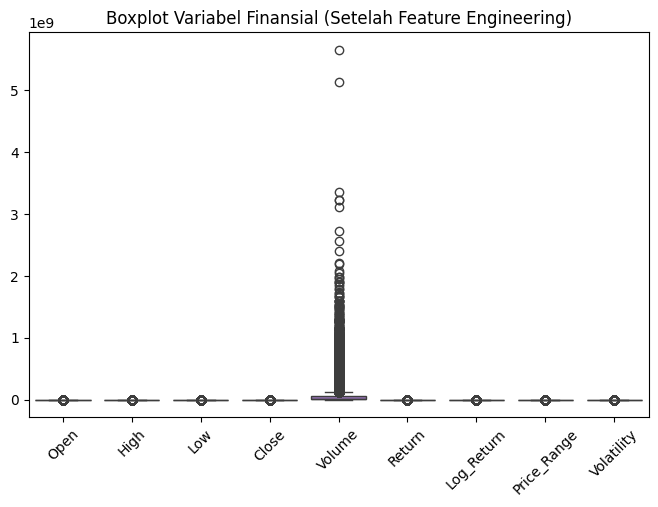

,Variable,Jumlah Outlier,Persentase (%)
0,Open,10616,7.772
1,High,10616,7.772
2,Low,10581,7.746
3,Close,10612,7.769
4,Volume,11458,8.388
5,Return,9221,6.750
6,Log_Return,9181,6.721
7,Price_Range,13791,10.096
8,Volatility,7098,5.196


In [54]:
# 4.2 Distribution Analysis
# Outlier Checking
financial_vars = ['Open','High','Low','Close','Volume',
                  'Return','Log_Return','Price_Range','Volatility']

# BOX PLOT
plt.figure(figsize=(8,5))
sns.boxplot(data=df1[financial_vars])
plt.title('Boxplot Variabel Finansial (Setelah Feature Engineering)')
plt.xticks(rotation=45)
plt.show()

# Outlier menggunakan IQR
outlier_result = []
for col in financial_vars:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = df1[(df1[col]<lower)|(df1[col]>upper)]
    outlier_result.append([
        col,
        len(outlier),
        round(len(outlier)/len(df1)*100,3)
    ])

outlier_table = pd.DataFrame(
    outlier_result,
    columns=['Variable','Jumlah Outlier','Persentase (%)']
)
outlier_table

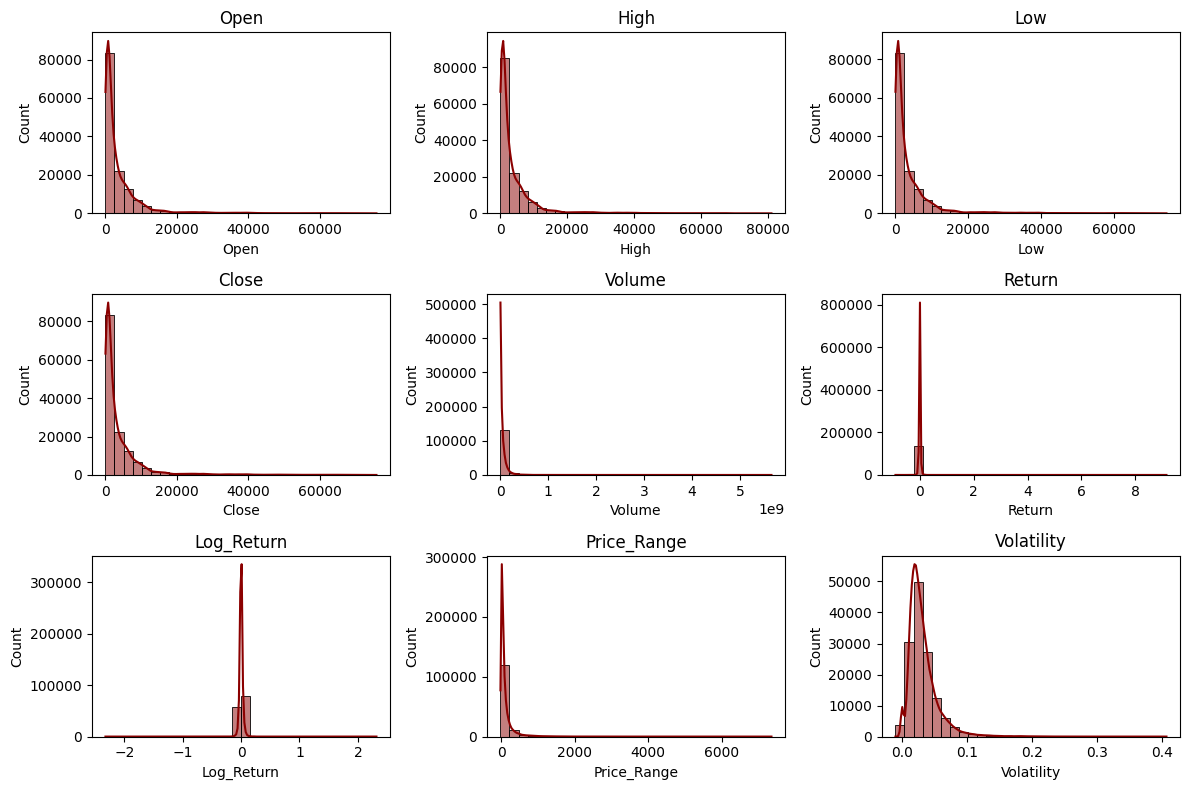

,Variable,Skewness
0,Open,4.495396
1,High,4.490872
2,Low,4.502140
3,Close,4.496403
4,Volume,10.923622
5,Return,122.853097
6,Log_Return,0.342884
7,Price_Range,6.616490
8,Volatility,2.643084


In [55]:
# HISTOGRAM DISTRIBUTION
plt.figure(figsize=(12,8))

for i,col in enumerate(financial_vars):
    plt.subplot(3,3,i+1)
    sns.histplot(
        df1[col],
        kde=True,
        bins=30,
        color='darkred'
    )
    plt.title(col)

plt.tight_layout()
plt.show()

# SKEWNESS VALUE
skewness = df1[financial_vars].skew()
skew_table = pd.DataFrame({
    'Variable':skewness.index,
    'Skewness':skewness.values
})
skew_table

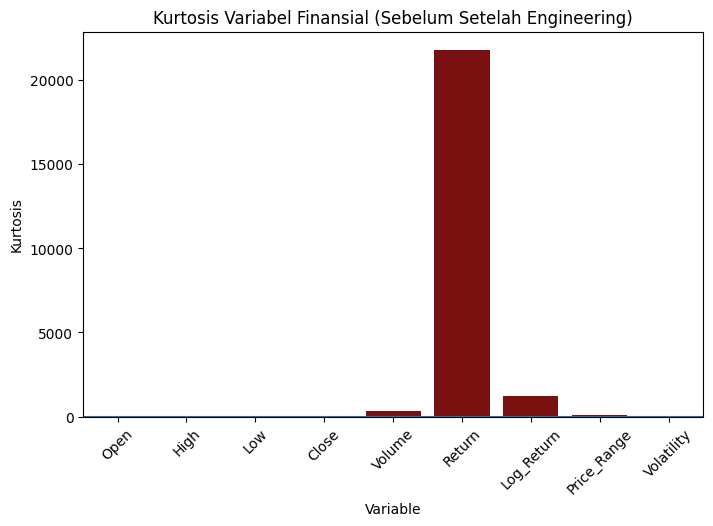

,Variable,Kurtosis
0,Open,26.272440
1,High,26.218526
2,Low,26.337269
3,Close,26.283434
4,Volume,338.502883
5,Return,21788.466628
6,Log_Return,1252.882615
7,Price_Range,80.477639
8,Volatility,13.525750


In [56]:
# KURTOSIS VALUE
kurt = df1[financial_vars].kurtosis()
kurt_table = pd.DataFrame({
    'Variable':kurt.index,
    'Kurtosis':kurt.values
})

# VISUALISASI KURTOSIS
plt.figure(figsize=(8,5))
sns.barplot(
    x=kurt_table['Variable'],
    y=kurt_table['Kurtosis'],
    color='darkred'
)

plt.axhline(0)
plt.title('Kurtosis Variabel Finansial (Sebelum Setelah Engineering)')
plt.xticks(rotation=45)
plt.show()

kurt_table

In [58]:
df1['Return'].abs().sort_values(ascending=False).head(20)

,Return
100643,9.153846
100648,9.137500
100641,8.950000
92537,1.111111
100642,0.902010
100640,0.900744
100647,0.900744
88685,0.493766
44866,0.466667
92928,0.443182


**Justifikasi penggunaan log return:**

Distribusi variabel `Return` menunjukkan nilai skewness (122.85) dan kurtosis (21788.47) yang sangat tinggi. Hal ini menunjukkan adanya **extreme values** yang menyebabkan distribusi menjadi sangat tidak normal (*heavy-tailed distribution*). Fenomena ini umum terjadi pada data saham, terutama pada saham berharga rendah atau akibat aksi korporasi seperti stock split.

Sebaliknya, variabel `Log_Return` memiliki skewness yang jauh lebih kecil (0.34) dan kurtosis yang lebih moderat (1252.88), sehingga distribusinya lebih stabil dan mendekati simetris.

Oleh karena itu, `Log_Return` digunakan sebagai variabel utama dalam analisis time series karena lebih **robust terhadap outlier**, lebih sesuai dengan asumsi model statistik, serta merupakan standar yang umum digunakan dalam analisis finansial.

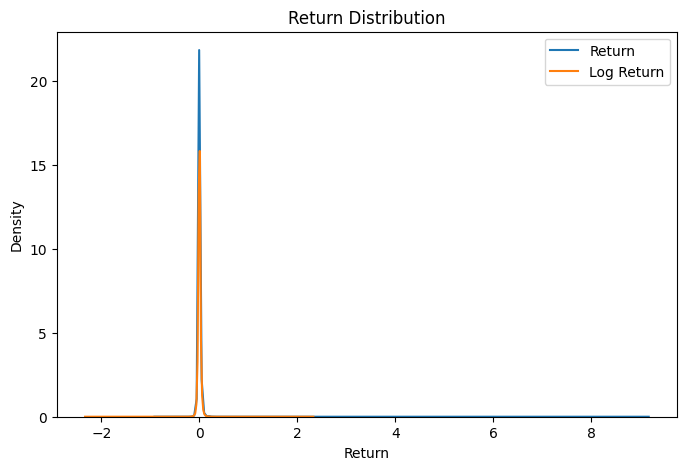

In [57]:
# KDE plot penting financial
plt.figure(figsize=(8,5))
sns.kdeplot(df1['Return'], label='Return')
sns.kdeplot(df1['Log_Return'], label='Log Return')
plt.legend()
plt.title('Return Distribution')
plt.show()

### Outlier

Analisis boxplot menunjukkan terdapat sejumlah outlier terutama pada variabel `Volume` dan `Price_Range`. Hal ini merupakan karakteristik umum data finansial karena aktivitas perdagangan saham sering mengalami lonjakan akibat informasi pasar atau sentimen investor.

Berdasarkan perhitungan IQR, persentase outlier relatif sedikit dibanding total observasi sehingga tidak dilakukan penghapusan data. Dalam konteks financial data, outlier justru dapat merepresentasikan **market shock** atau **abnormal trading activity** sehingga tetap dipertahankan.

### Skewness

Hasil analisis skewness menunjukkan beberapa variabel seperti `Volume` memiliki distribusi right-skewed. Hal ini menunjukkan sebagian besar hari memiliki volume transaksi normal dengan beberapa hari memiliki volume sangat tinggi.

Distribusi return yang tidak simetris merupakan karakteristik umum financial time series karena adanya asymmetric risk dalam pergerakan harga saham.

### Kurtosis

Nilai kurtosis menunjukkan beberapa variabel terutama `Return` memiliki nilai positif yang mengindikasikan heavy tail distribution. Hal ini menunjukkan adanya kemungkinan pergerakan ekstrem yang lebih besar dibanding distribusi normal.

Karakteristik ini umum ditemukan pada data saham karena volatilitas pasar tidak selalu konstan.

> Karakteristik skewness tinggi dan kurtosis positif menunjukkan data finansial tidak mengikuti distribusi normal sehingga analisis lanjutan perlu mempertimbangkan metode yang robust terhadap non-normality.


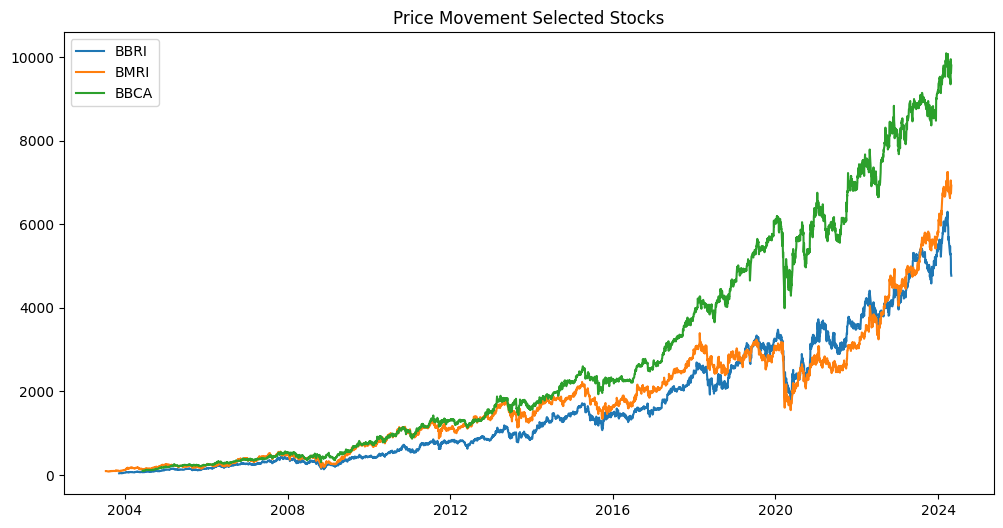

In [59]:
# 4.3 Time Series Visualization
# Top 3 saham volume terbesar
top_stock = df1.groupby('Stock_Name')['Volume'].mean().sort_values(ascending=False).head(3)
top_stock = top_stock.index
plt.figure(figsize=(12,6))

for stock in top_stock:
    temp = df1[df1['Stock_Name']==stock]
    plt.plot(
        temp['Date'],
        temp['Close'],
        label=stock
    )
plt.legend()
plt.title('Price Movement Selected Stocks')
plt.show()

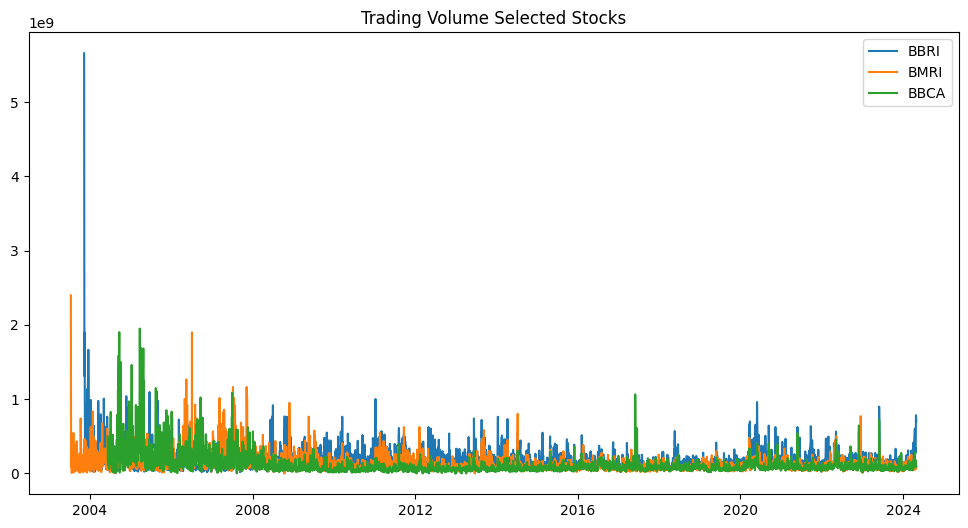

In [60]:
# Volume trend
plt.figure(figsize=(12,6))
for stock in top_stock:
    temp = df1[df1['Stock_Name']==stock]
    plt.plot(
        temp['Date'],
        temp['Volume'],
        label=stock
    )
plt.legend()
plt.title('Trading Volume Selected Stocks')
plt.show()

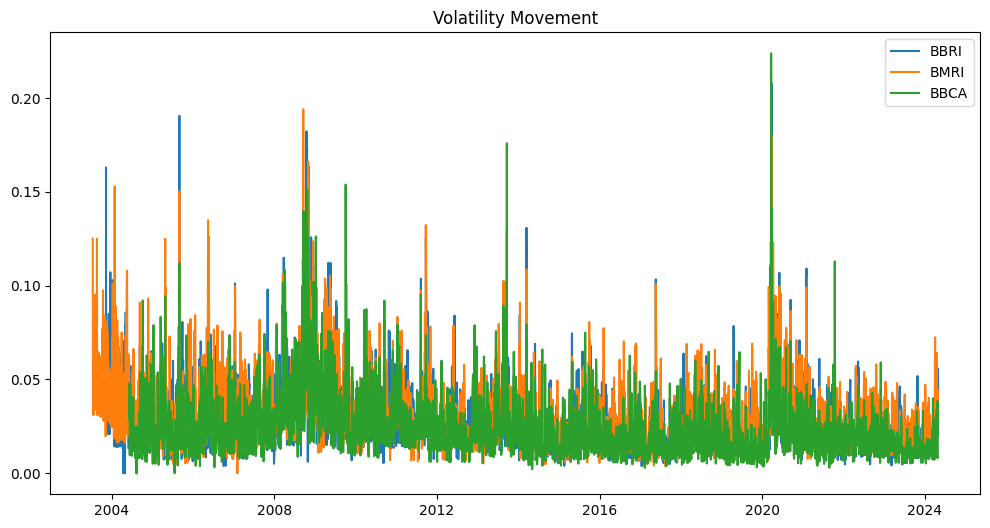

In [61]:
# Volatility time series
plt.figure(figsize=(12,6))
for stock in top_stock:
    temp = df1[df1['Stock_Name']==stock]
    plt.plot(
        temp['Date'],
        temp['Volatility'],
        label=stock
    )
plt.legend()
plt.title('Volatility Movement')
plt.show()

In [23]:
# 4.4 Correlation Analysis
corr_vars = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Return',
    'Log_Return',
    'Price_Range',
    'Volatility'
]
corr = df1[corr_vars].corr()
corr

,Open,High,Low,Close,Volume,Return,Log_Return,Price_Range,Volatility
Open,1.000000,0.999865,0.999873,0.999770,-0.171647,-0.018950,-0.008243,0.808258,-0.089340
High,0.999865,1.000000,0.999826,0.999883,-0.171321,-0.014028,-0.005198,0.814012,-0.084983
Low,0.999873,0.999826,1.000000,0.999872,-0.171641,-0.014782,-0.005762,0.803048,-0.093211
Close,0.999770,0.999883,0.999872,1.000000,-0.171422,-0.010541,-0.001436,0.808872,-0.088904
Volume,-0.171647,-0.171321,-0.171641,-0.171422,1.000000,0.090691,0.100654,-0.128545,0.254529
Return,-0.018950,-0.014028,-0.014782,-0.010541,0.090691,1.000000,0.549148,0.012176,0.107431
Log_Return,-0.008243,-0.005198,-0.005762,-0.001436,0.100654,0.549148,1.000000,0.013401,0.068434
Price_Range,0.808258,0.814012,0.803048,0.808872,-0.128545,0.012176,0.013401,1.000000,0.187778
Volatility,-0.089340,-0.084983,-0.093211,-0.088904,0.254529,0.107431,0.068434,0.187778,1.000000


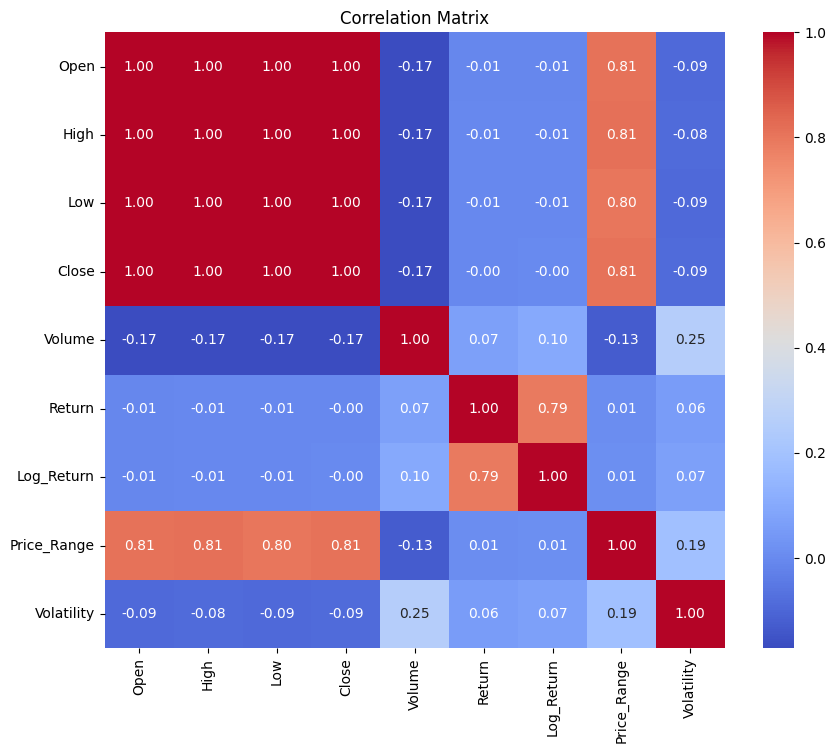

In [64]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [65]:
# 4.5 Cross Stock Comparison
# Volatility per saham
stock_volatility = df1.groupby('Stock_Name')['Return'].std()
stock_volatility = stock_volatility.sort_values()
stock_volatility

,Return
Stock_Name,
BBCA,0.018981
TLKM,0.019605
UNVR,0.020529
ICBP,0.023411
GGRM,0.023713
INDF,0.023719
ASII,0.024120
BMRI,0.024564
BBRI,0.024565


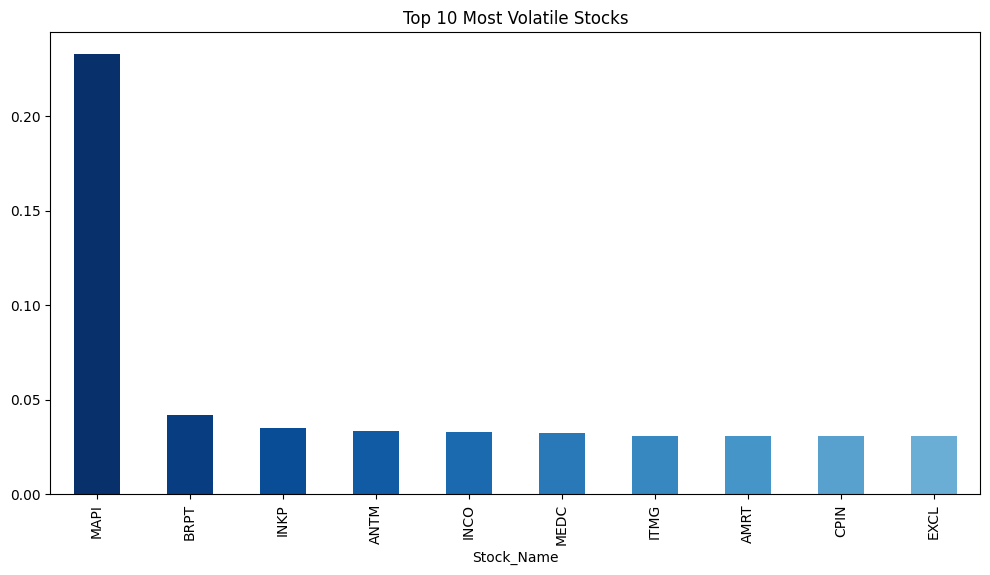

In [66]:
# Plot: Volatility per saham
top10 = stock_volatility.sort_values(ascending=False).head(10)
colors = plt.cm.Blues(np.linspace(1, 0.5, len(top10)))
plt.figure(figsize=(12,6))
top10.plot(
    kind='bar',
    color=colors
)

plt.title("Top 10 Most Volatile Stocks")
plt.show()

In [ ]:
# Most stable stocks
stock_volatility.sort_values().dropna()

,Return
Stock_Name,
BBCA,0.013875
GGRM,0.018363
BBRI,0.018468
ASII,0.018832
BMRI,0.019043
BBNI,0.019502
AKRA,0.020550
ACES,0.021327
ADRO,0.021856


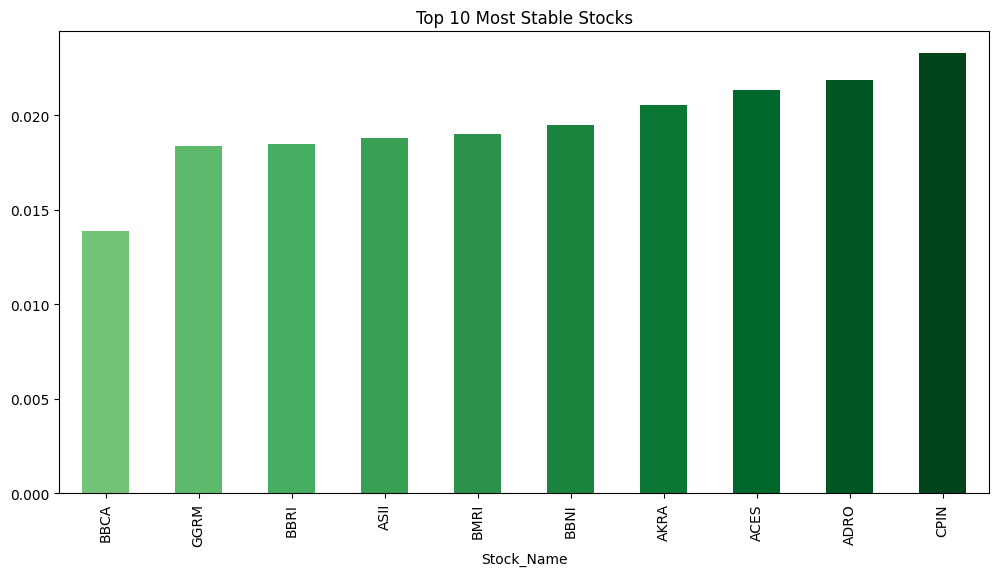

In [ ]:
# Plot: Most stable stocks
most_stable = stock_volatility.sort_values().dropna().head(10)
colors = plt.cm.Greens(np.linspace(0.5, 1, len(most_stable)))
plt.figure(figsize=(12,6))
most_stable.plot(
    kind='bar',
    color=colors
)

plt.title("Top 10 Most Stable Stocks")
plt.show()

In [72]:
# Volume Comparison
stock_volume = df1.groupby('Stock_Name')['Volume'].mean()
stock_volume

,Volume
Stock_Name,
ACES,2.160271e+07
ADRO,6.480496e+07
AKRA,5.069930e+07
AMRT,9.066073e+06
ANTM,8.659453e+07
ASII,4.289193e+07
BBCA,1.103947e+08
BBNI,5.060374e+07
BBRI,1.778778e+08


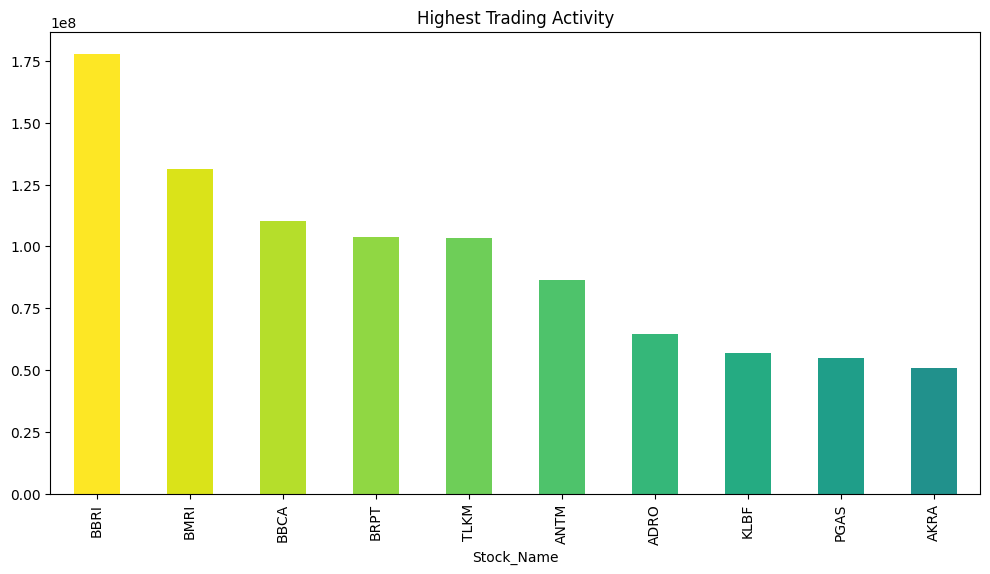

In [75]:
# Plot: Volume Comparison
colors = plt.cm.viridis(np.linspace(1, 0.5, len(top10)))
plt.figure(figsize=(12,6))
stock_volume.sort_values(ascending=False).head(10).plot(
    kind='bar',
    color=colors
)
plt.title("Highest Trading Activity")
plt.show()

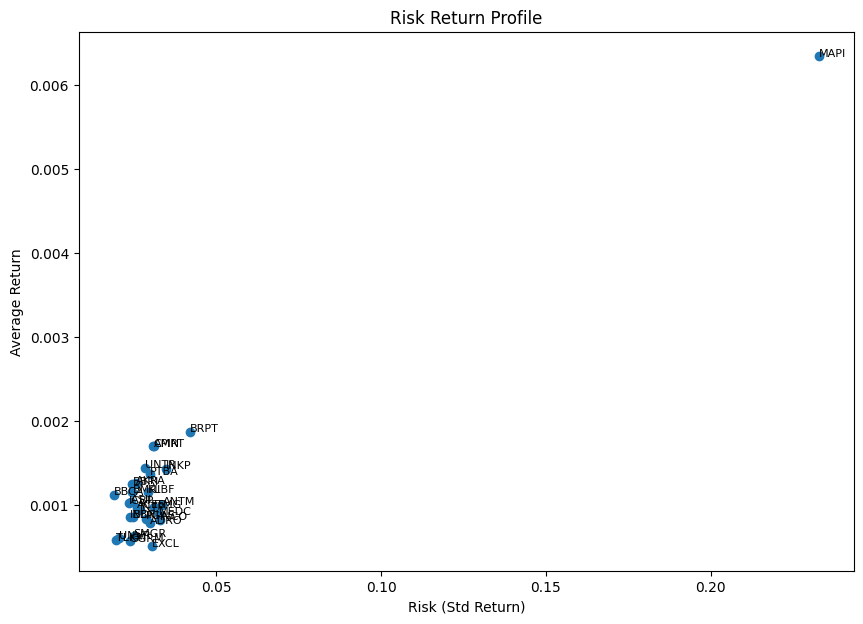

In [106]:
# Risk vs Return map
risk_return = df1.groupby('Stock_Name').agg({
    'Return':'mean',
    'Return':'std'
})
risk_return.columns = ['Risk']
risk_return['Return'] = df1.groupby('Stock_Name')['Return'].mean()

plt.figure(figsize=(10,7))
plt.scatter(
    risk_return['Risk'],
    risk_return['Return']
)

for i in risk_return.index:
    plt.text(
        risk_return.loc[i,'Risk'],
        risk_return.loc[i,'Return'],
        i,
        fontsize=8
    )
plt.xlabel("Risk (Std Return)")
plt.ylabel("Average Return")
plt.title("Risk Return Profile")
plt.show()

## **Decision Framework Berbasis Data**

In [109]:
# STEP 1: Risk Return Table
risk_return = df1.groupby('Stock_Name').agg({'Log_Return':['mean','std']})
risk_return.columns=['Return','Risk']
risk_return=risk_return.dropna()
print('Risk return table: \n', risk_return)

# STEP 2: Score (Sharpe proxy)
# Return tinggi + risk rendah = bagus
risk_return['Score']=risk_return['Return']/risk_return['Risk']
risk_return.sort_values('Score',ascending=False)

# STEP 3: Classification investor profile
# Threshold
risk_mean=risk_return['Risk'].mean()
return_mean=risk_return['Return'].mean()

def classify(row):
    if row['Risk']>risk_mean and row['Return']>return_mean:
        return 'High Risk High Return'
    if row['Risk']<risk_mean and row['Return']>return_mean:
        return 'Efficient Performer'
    if row['Risk']<risk_mean and row['Return']<return_mean:
        return 'Stable Defensive'
    return 'Speculative'
risk_return['Category']=risk_return.apply(classify,axis=1)
risk_return.sort_values('Return',ascending=False)

# STEP 4: Investor recommendation table
high=risk_return[
risk_return['Category']=='High Risk High Return'
].sort_values('Return',ascending=False)

stable=risk_return[
risk_return['Category']=='Stable Defensive'
].sort_values('Risk')

efficient=risk_return[
risk_return['Category']=='Efficient Performer'
].sort_values('Score',ascending=False)

print('\nInvestor recommendation table:')
print(high.head())
print(stable.head())
print(efficient.head())

Risk return table: 
               Return      Risk
Stock_Name                    
ACES        0.000640  0.025621
ADRO        0.000346  0.029776
AKRA        0.000934  0.025528
AMRT        0.001232  0.030587
ANTM        0.000439  0.033773
ASII        0.000747  0.024040
BBCA        0.000948  0.018924
BBNI        0.000554  0.024597
BBRI        0.000954  0.024416
BMRI        0.000852  0.024449
BRPT        0.001028  0.040764
CPIN        0.001235  0.030549
EXCL        0.000052  0.030302
GGRM        0.000299  0.023495
ICBP        0.000753  0.023302
INCO        0.000298  0.032479
INDF        0.000576  0.023637
INKP        0.000846  0.034134
INTP        0.000589  0.026844
ITMG        0.000507  0.030541
KLBF        0.000785  0.026354
MAPI        0.000705  0.087326
MEDC        0.000375  0.032073
PGAS        0.000432  0.028592
PTBA        0.000923  0.029919
SMGR        0.000326  0.024926
TLKM        0.000397  0.019543
UNTR        0.001048  0.028157
UNVR        0.000397  0.020393

Investor recommen

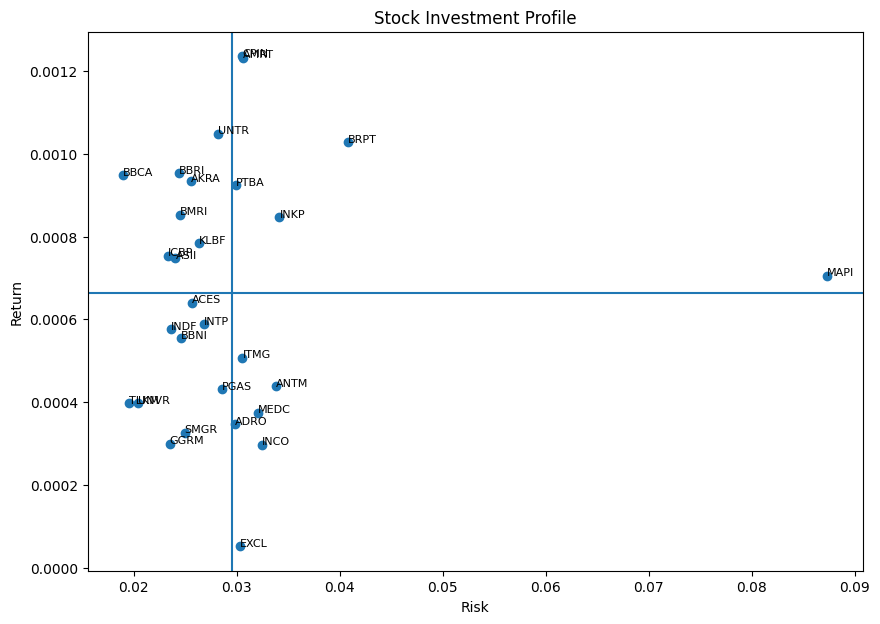

In [110]:
# STEP 5: Risk Return Map
plt.figure(figsize=(10,7))
plt.scatter(
risk_return['Risk'],
risk_return['Return']
)
plt.axvline(risk_mean)
plt.axhline(return_mean)

for i in risk_return.index:
    plt.text(
        risk_return.loc[i,'Risk'],
        risk_return.loc[i,'Return'],
        i,
        fontsize=8
    )

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Stock Investment Profile")
plt.show()

In [111]:
# STEP 6: Final Recommendation Table
recommendation=risk_return.sort_values('Score',ascending=False)
recommendation[['Return','Risk','Score','Category']].head(10)

,Return,Risk,Score,Category
Stock_Name,,,,
BBCA,0.000948,0.018924,0.050119,Efficient Performer
CPIN,0.001235,0.030549,0.040442,High Risk High Return
AMRT,0.001232,0.030587,0.040270,High Risk High Return
BBRI,0.000954,0.024416,0.039056,Efficient Performer
UNTR,0.001048,0.028157,0.037228,Efficient Performer
AKRA,0.000934,0.025528,0.036601,Efficient Performer
BMRI,0.000852,0.024449,0.034860,Efficient Performer
ICBP,0.000753,0.023302,0.032336,Efficient Performer
ASII,0.000747,0.024040,0.031092,Efficient Performer


## **EDA checklist (8 plot powerful financial analysis)**

### 1. Price normalization plot
- Masalah harga saham:
BBCA 60000 vs ACES 700 → tidak comparable.
- Solusi: normalize price.
- Insight: saham mana yang relatif perform better.

### 2. Return distribution
- Insight: fat tail, market risk.

### 3. Volatility clustering
- Financial data tidak random: volatility muncul berkelompok.
- Insight: crisis period detection.

### 4. Volume spike detection (behavior insight)
- Insight: abnormal trading.

### 5. Risk vs Return map (sudah dibuat)
- Ini sudah termasuk top tier EDA, tapi perlu tambahkan quadrant line:
- Insight: optimal stock zone.

### 6. Correlation antar saham (bukan antar variabel)
- Insight: diversification potential.

### 7. Drawdown analysis (HIGH LEVEL FINANCIAL EDA)
- Ini sering dipakai hedge fund.
- Insight: worst loss history.

### 8. Moving average crossover (technical behaviour)
- Insight: trend shift.

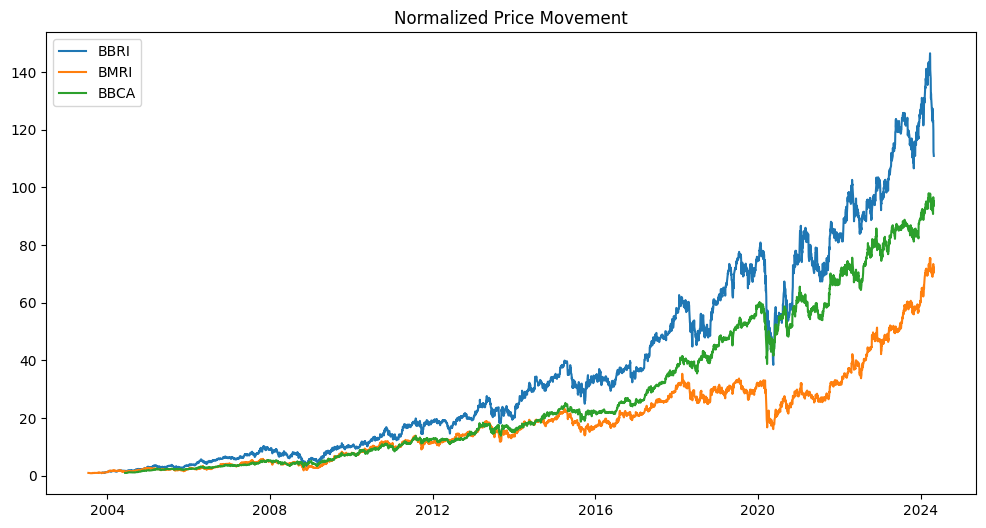

In [112]:
# Price normalization
plt.figure(figsize=(12,6))
for stock in top_stock:
    temp = df1[df1['Stock_Name']==stock].copy()
    temp['Norm_Price'] = temp['Close']/temp['Close'].iloc[0]
    plt.plot(
        temp['Date'],
        temp['Norm_Price'],
        label=stock
    )
plt.legend()
plt.title("Normalized Price Movement")
plt.show()

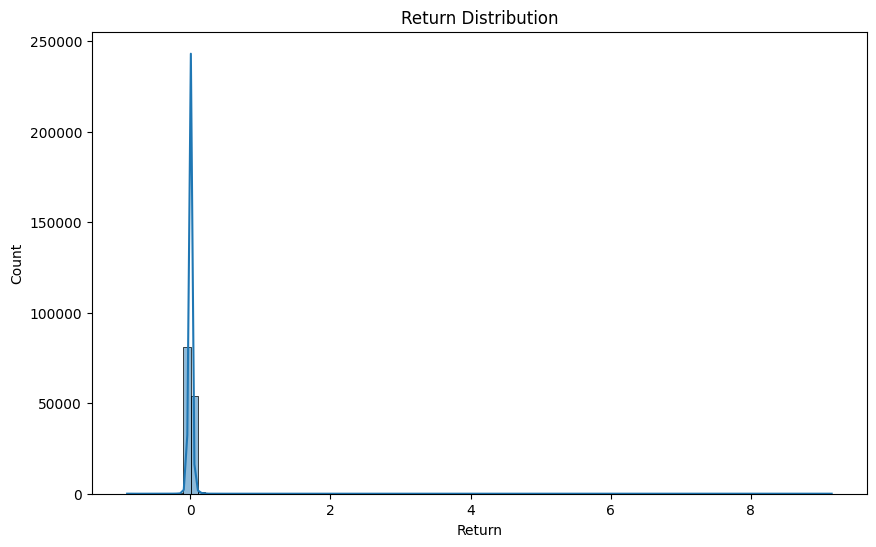

In [113]:
# Return distribution
plt.figure(figsize=(10,6))
sns.histplot(
    df1['Return'],
    bins=100,
    kde=True
)
plt.title("Return Distribution")
plt.show()

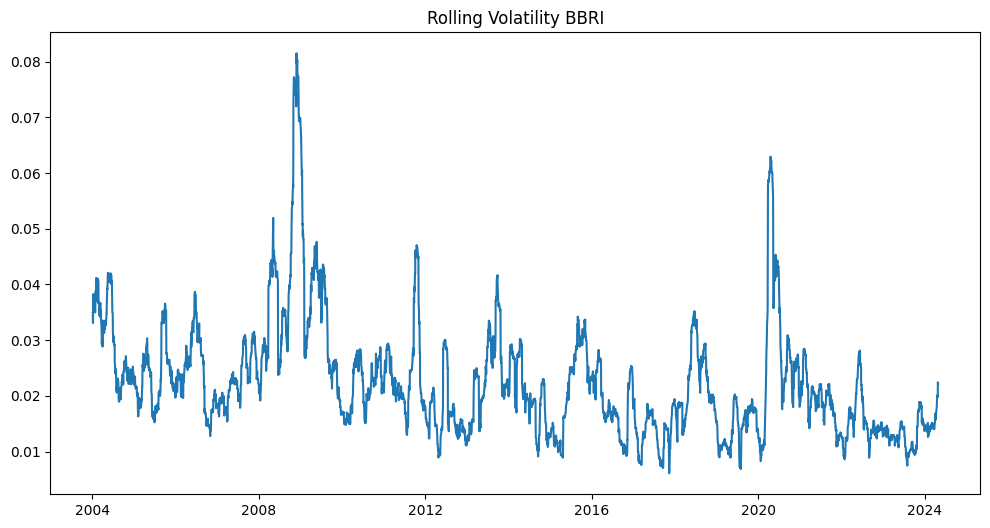

In [114]:
# Volatility clustering
plt.figure(figsize=(12,6))
stock = 'BBRI'
temp = df1[df1['Stock_Name']==stock]
plt.plot(
    temp['Date'],
    temp['Return'].rolling(30).std()
)
plt.title("Rolling Volatility BBRI")
plt.show()

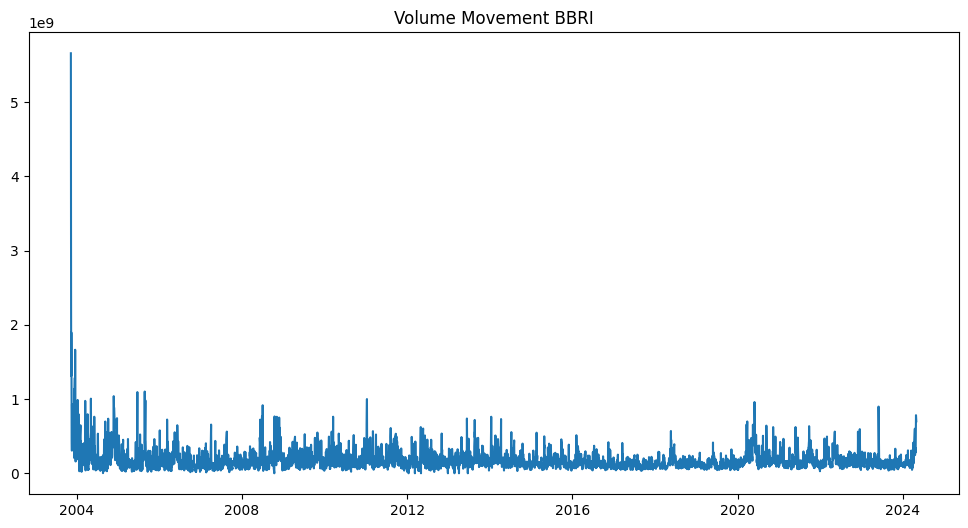

In [115]:
# Volume spike detection (behavior insight)
stock='BBRI'
temp = df1[df1['Stock_Name']==stock]
plt.figure(figsize=(12,6))
plt.plot(
    temp['Date'],
    temp['Volume']
)
plt.title("Volume Movement BBRI")
plt.show()

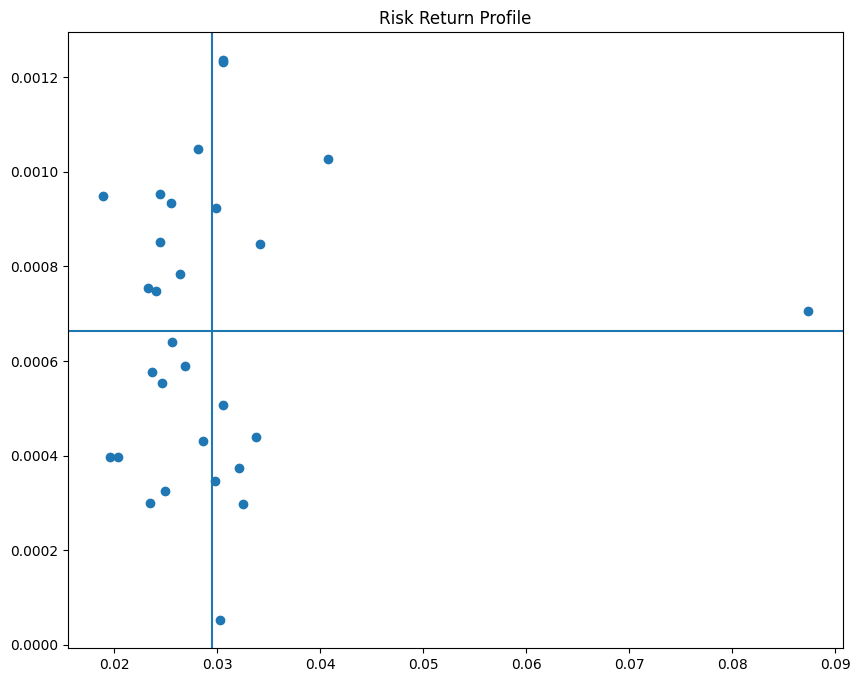

In [116]:
# Risk vs Return map
plt.figure(figsize=(10,8))
plt.scatter(
    risk_return['Risk'],
    risk_return['Return']
)
plt.axvline(risk_return['Risk'].mean())
plt.axhline(risk_return['Return'].mean())
plt.title("Risk Return Profile")
plt.show()

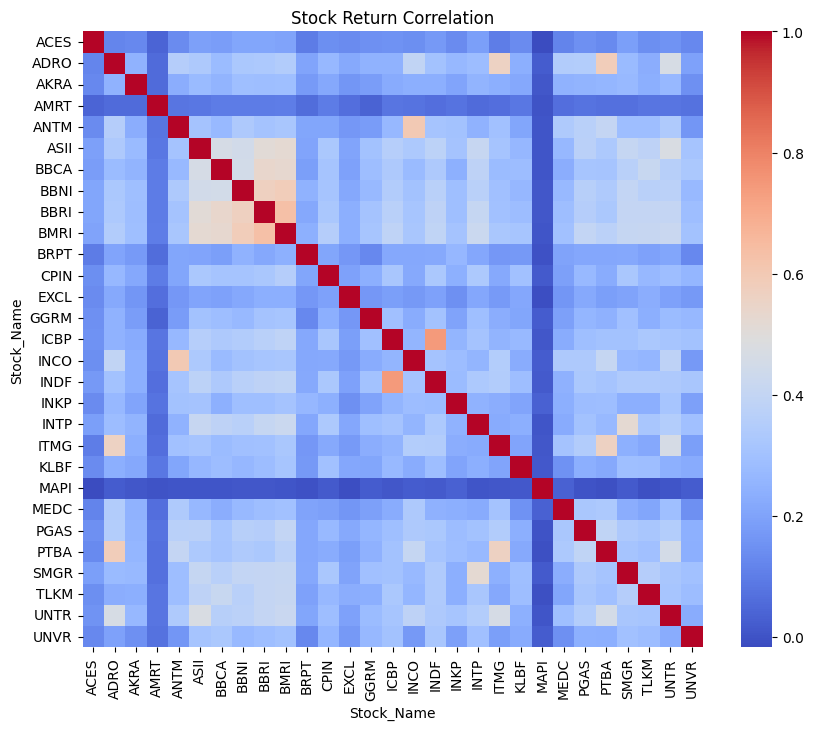

In [120]:
# Correlation antar saham
pivot = df1.pivot(
    index='Date',
    columns='Stock_Name',
    values='Return'
)
corr_stock = pivot.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_stock,
    cmap='coolwarm'
)
plt.title("Stock Return Correlation")
plt.show()

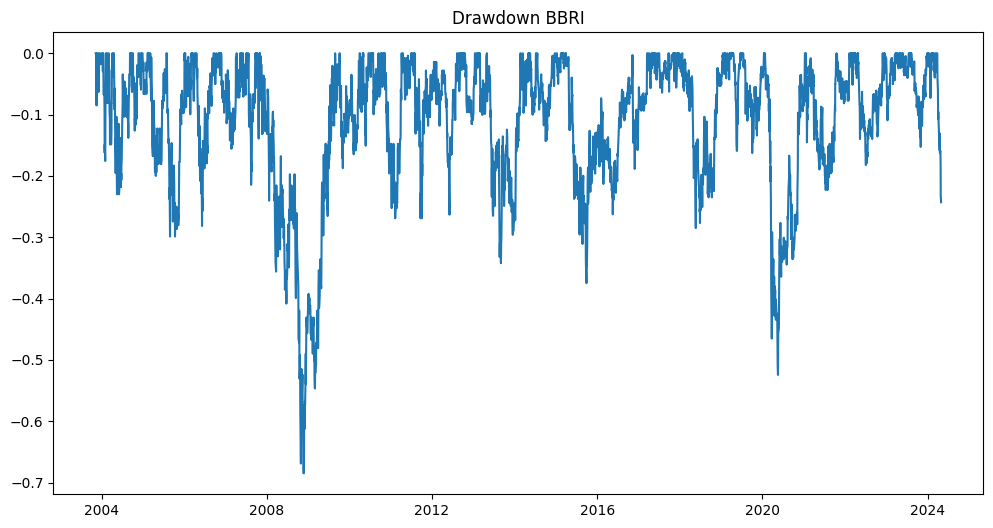

In [121]:
# Drawdown analysis
stock='BBRI'
temp=df1[df1['Stock_Name']==stock].copy()
temp['cummax']=temp['Close'].cummax()
temp['drawdown']=(temp['Close']-temp['cummax'])/temp['cummax']
plt.figure(figsize=(12,6))
plt.plot(
    temp['Date'],
    temp['drawdown']
)
plt.title("Drawdown BBRI")
plt.show()

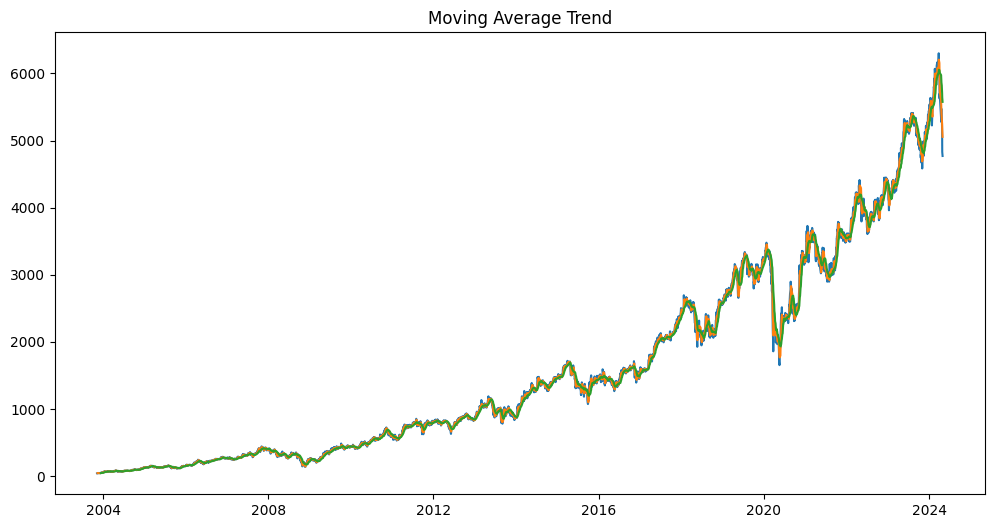

In [122]:
# Moving average crossover (technical behaviour)
stock='BBRI'
temp=df1[df1['Stock_Name']==stock]
plt.figure(figsize=(12,6))
plt.plot(temp['Date'],temp['Close'])
plt.plot(temp['Date'],temp['MA_5'])
plt.plot(temp['Date'],temp['MA_20'])
plt.title("Moving Average Trend")
plt.show()

# 5. Initial Insight Development

## 5.1. Price Behaviour Insight

Insight awal mengenai:

- Stabilitas harga.
- Perubahan tren.
- Pergerakan ekstrem.

## 5.2. Trading Activity Insight

Analisis:

- Volume spikes.
- Aktivitas tinggi.

## 5.3. Risk Proxy Exploration

Menggunakan:

- Std return.
- Daily range.

Tujuan:

Mengidentifikasi risiko relatif.

## 5.4. Data Limitation Assessment

Menilai apakah:

Dataset cukup untuk:

- Forecasting
- Risk modeling
- Portfolio analysis

Atau perlu:

External data seperti:
- IHSG
- Inflasi
- Interest rate

# 6. Potential Analysis Direction

Bagian ini merumuskan kemungkinan arah analisis lanjutan.

Contoh:
Direction 1: Forecasting harga saham.
Direction 2: Volatility modeling.
Direction 3: Stock clustering.
Direction 4: Portfolio structure analysis.
Direction 5: Anomaly detection.

Tujuan bab ini:
Menentukan arah paling rasional berdasarkan EDA.

---

In [87]:
# TIME SERIES LIBRARY
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

In [123]:
# Pilih saham representatif
stock='BBRI'
ts=df1[df1['Stock_Name']==stock].copy()
ts=ts.sort_values('Date')
ts.set_index('Date',inplace=True)
ts.head()

,Stock_Name,Open,High,Low,Close,Volume,Return,Log_Return,Price_Range,Volatility,MA_5,MA_20,Year,Month,Day,MA5_available,MA20_available
Date,,,,,,,,,,,,,,,,,
2003-11-10,BBRI,47,49,42,43,5658651738,NaN,0.000000,7,0.162791,NaN,NaN,2003,11,10,0,0
2003-11-11,BBRI,43,44,42,44,3232466332,0.023256,0.022990,2,0.045455,NaN,NaN,2003,11,11,0,0
2003-11-12,BBRI,43,47,43,47,2203244555,0.068182,0.065958,4,0.085106,NaN,NaN,2003,11,12,0,0
2003-11-13,BBRI,47,47,45,47,1309077610,0.000000,0.000000,2,0.042553,NaN,NaN,2003,11,13,0,0
2003-11-14,BBRI,47,47,44,47,1897824280,0.000000,0.000000,3,0.063830,45.6,NaN,2003,11,14,1,0


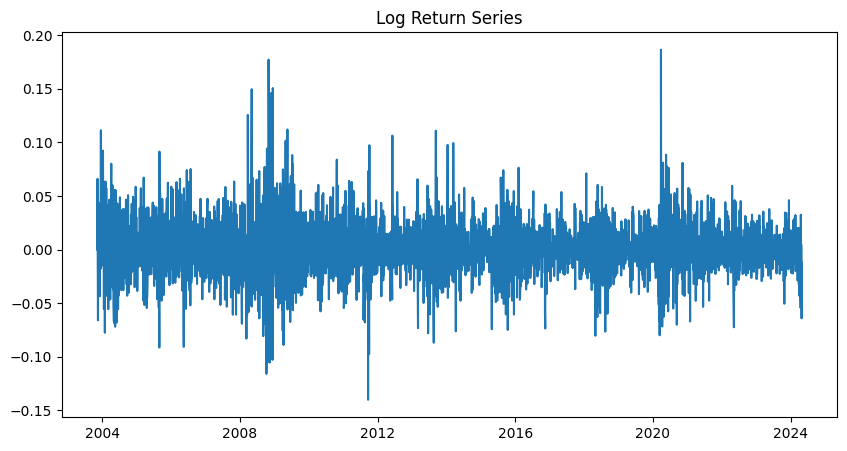

In [124]:
# Gunakan return (bukan price), karena eturn lebih stationary
series=ts['Log_Return'].dropna()
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Log Return Series")
plt.show()

In [125]:
# Stationarity test (ADF)
result=adfuller(series)
print("ADF Statistic:",result[0])
print("p-value:",result[1])

# Jika p < 0.05, maka stationary. Kalau sudah stationary, tidak perlu differencing.

ADF Statistic: -24.216767175607263
p-value: 0.0


<Figure size 1000x500 with 0 Axes>

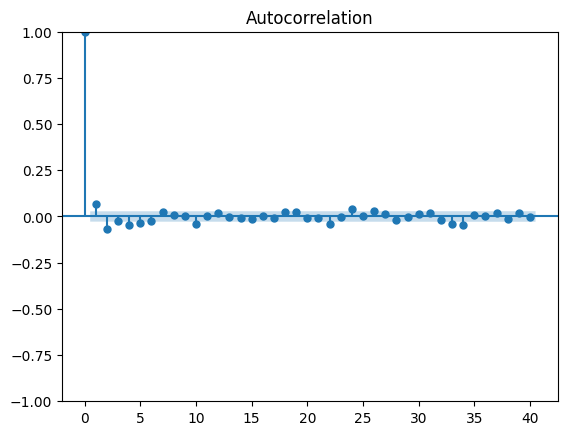

<Figure size 1000x500 with 0 Axes>

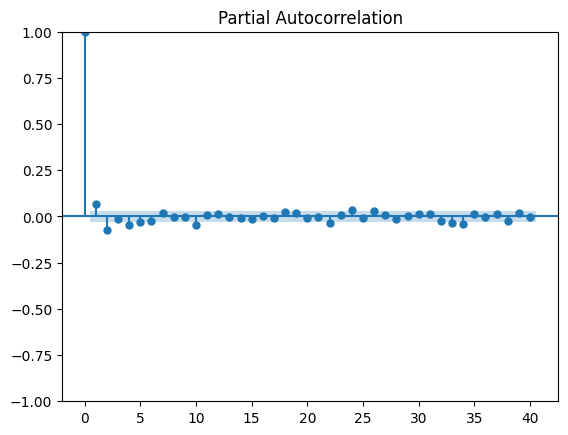

In [91]:
# ACF PACF, untuk menentukan AR MA order.
plt.figure(figsize=(10,5))
plot_acf(series,lags=40)
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(series,lags=40)
plt.show()

In [129]:
# Train test split, karena forecast harus valid.
train_size=int(len(series)*0.8)
train=series[:train_size]
test=series[train_size:]
len(train),len(test)

(3950, 988)

In [130]:
# ARIMA modelling
model=ARIMA(train,order=(1,0,1))
model_fit=model.fit()
model_fit.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Log_Return   No. Observations:                 3950
Model:                 ARIMA(1, 0, 1)   Log Likelihood                8945.471
Date:                Sat, 28 Mar 2026   AIC                         -17882.943
Time:                        09:29:15   BIC                         -17857.817
Sample:                             0   HQIC                        -17874.030
                               - 3950                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.187      0.029    9.85e-05       0.002
ar.L1         -0.2527      0.100     -2.521      0.012      -0.449      -0.056
ma.L1          0.3523      0.099      3.559      0.000       0.158       0.546
sigma2         0.0006   8.78e-06     71.881      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):              1935.99
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.38   Skew:                             0.20
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


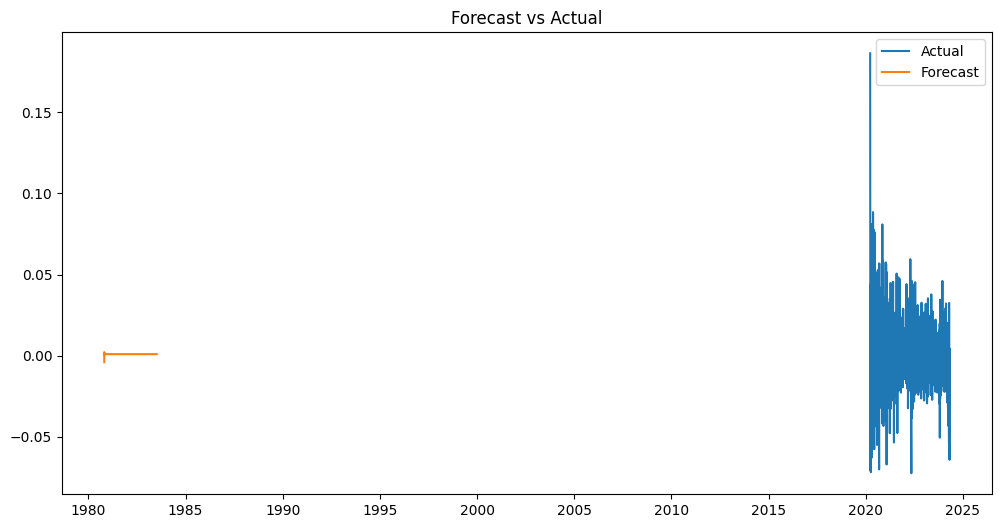

In [131]:
# Forecast
forecast=model_fit.forecast(
    steps=len(test)
)
plt.figure(figsize=(12,6))
plt.plot(test,label='Actual')
plt.plot(forecast,label='Forecast')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [136]:
# Evaluation
rmse=np.sqrt(
    mean_squared_error(test,forecast)
)
rmse

np.float64(0.02071287621602035)

In [138]:
# Rolling forecast
history=list(train)
predictions=[]
for t in range(len(test)):
    model=ARIMA(history,order=(1,0,1))
    model_fit=model.fit()
    yhat=model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test[t])

/tmp/ipykernel_6244/478639090.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  history.append(test[t])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [140]:
rmse=np.sqrt(
    mean_squared_error(test,predictions)
)
rmse

np.float64(0.020774953386125405)

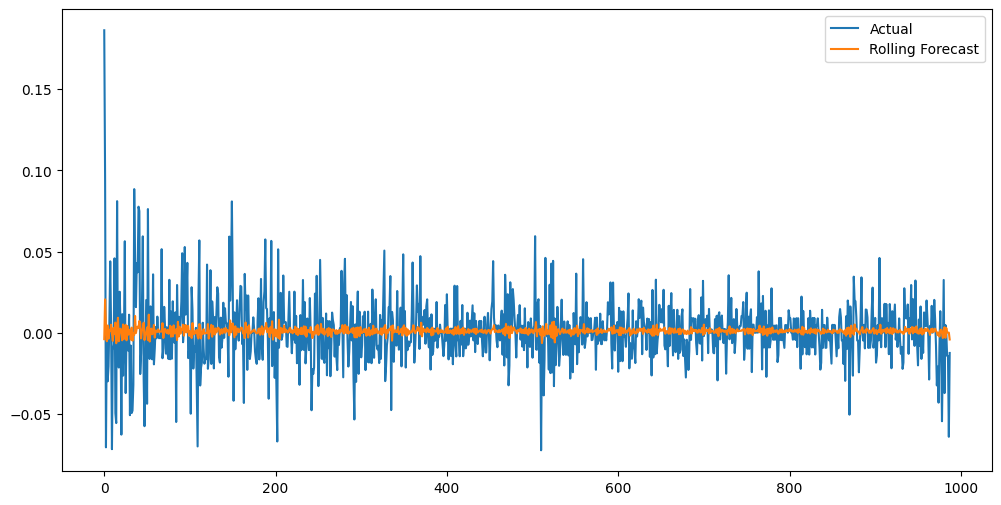

In [141]:
plt.figure(figsize=(12,6))
plt.plot(test.values,label='Actual')
plt.plot(predictions,label='Rolling Forecast')
plt.legend()
plt.show()

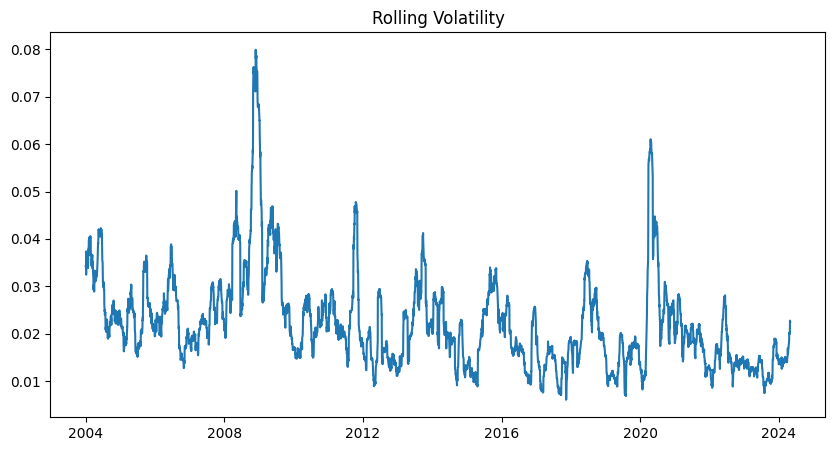

In [142]:
# Volatility forecast
ts['Rolling_Vol']=ts['Log_Return'].rolling(30).std()
plt.figure(figsize=(10,5))
plt.plot(ts['Rolling_Vol'])
plt.title("Rolling Volatility")
plt.show()

In [143]:
# Financial interpretation
series.mean()

np.float64(0.0009536049955829951)

In [144]:
# Risk
series.std()

# Sharpe proxy
series.mean()/series.std()

np.float64(0.039056303395164325)

# Insight Time Series Forecasting Saham BBRI

Berdasarkan hasil uji Augmented Dickey Fuller (ADF), nilai p-value sebesar 0.000 menunjukkan bahwa data log return saham BBRI bersifat stasioner. Hal ini menunjukkan bahwa pergerakan return saham cenderung berfluktuasi di sekitar nilai rata-rata yang konstan sehingga sesuai untuk dimodelkan menggunakan pendekatan ARIMA tanpa proses differencing tambahan.

Model ARIMA(1,0,1) menunjukkan parameter AR dan MA yang signifikan, yang mengindikasikan bahwa pergerakan return saham BBRI masih memiliki ketergantungan jangka pendek terhadap pergerakan sebelumnya. Hal ini menunjukkan bahwa meskipun pasar saham cenderung sulit diprediksi secara jangka panjang, terdapat pola dependensi jangka pendek yang masih dapat dimanfaatkan untuk analisis risiko.

Nilai RMSE sebesar 0.0207 menunjukkan bahwa model memiliki tingkat error prediksi yang relatif kecil terhadap skala log return, sehingga model dapat dikatakan cukup baik dalam menangkap pola fluktuasi return harian saham BBRI.

Hasil forecasting menunjukkan bahwa rata-rata log return yang diprediksi berada di sekitar 0.00094, yang mengindikasikan adanya kecenderungan return positif dalam jangka pendek, meskipun dengan tingkat volatilitas yang relatif rendah. Hal ini menunjukkan bahwa saham BBRI cenderung memiliki pertumbuhan stabil dibandingkan saham dengan volatilitas tinggi.

Analisis rolling volatility menunjukkan rata-rata volatilitas sebesar 0.022 dengan maksimum 0.079 yang menunjukkan bahwa risiko saham BBRI relatif terkendali dibanding saham spekulatif. Hal ini menguatkan karakteristik BBRI sebagai saham blue chip dengan profil risiko moderat.

Selain itu, rasio return terhadap risiko (Sharpe proxy) sebesar 0.039 menunjukkan bahwa saham BBRI memiliki efisiensi return terhadap risiko yang cukup baik, sehingga dapat dikategorikan sebagai saham yang relatif optimal untuk investor dengan profil risiko moderat hingga konservatif.

# Insight Investment Implication

Berdasarkan hasil analisis time series dan risk-return profiling, saham BBRI dapat dikategorikan sebagai saham dengan karakteristik:

1. Return stabil dengan kecenderungan positif dalam jangka panjang.
2. Risiko moderat dibanding saham volatilitas tinggi.
3. Likuiditas tinggi berdasarkan volume perdagangan.
4. Cocok untuk strategi investasi jangka menengah hingga panjang.

Dengan demikian, saham BBRI lebih sesuai untuk investor yang mengutamakan stabilitas pertumbuhan dibanding spekulasi jangka pendek, serta dapat dipertimbangkan sebagai komponen portofolio defensif dalam strategi diversifikasi.

# Insight metodologis

Penggunaan log return dalam modeling terbukti lebih stabil dibanding simple return karena mampu mengurangi pengaruh extreme price movement. Selain itu, pendekatan ARIMA memungkinkan identifikasi struktur dependensi jangka pendek yang tidak terlihat pada analisis deskriptif biasa.

Hal ini menunjukkan bahwa kombinasi exploratory data analysis dan time series modeling mampu memberikan insight yang lebih komprehensif dibanding hanya analisis statistik deskriptif.

# Kesimpulan insight utama

Secara keseluruhan, hasil analisis menunjukkan bahwa saham BBRI memiliki karakteristik return yang relatif stabil dengan risiko yang terkendali, sehingga lebih cocok dikategorikan sebagai saham investasi dibanding saham trading spekulatif. Model time series juga menunjukkan bahwa meskipun prediksi harga saham memiliki keterbatasan, analisis return tetap memberikan informasi penting mengenai stabilitas dan profil risiko saham.